# 1.Missing value check

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("asthma_disease_data.csv")

In [3]:
df_cleaned = df.drop(columns=["PatientID", "DoctorInCharge"])

In [4]:
missing_values = df_cleaned.isnull().sum()

In [5]:
# Step 5: Filter only columns with missing values
missing = missing_values[missing_values > 0]

# Step 6: Display result
if missing.empty:
    print("✅ The dataset has no missing values. All columns are complete.")
else:
    print("⚠️ Missing values found in the following columns:")
    print(missing)

✅ The dataset has no missing values. All columns are complete.


# 2.Outlier check

In [8]:
# STEP 1: Create the FEV1/FVC Ratio column
df_cleaned["FEV1_FVC_Ratio"] = df_cleaned["LungFunctionFEV1"] / df_cleaned["LungFunctionFVC"]

In [9]:

# STEP 2: List of continuous features to check for outliers
continuous_features = [
    "Age", "BMI", "PhysicalActivity", "DietQuality", "SleepQuality",
    "PollutionExposure", "PollenExposure", "DustExposure",
    "LungFunctionFEV1", "LungFunctionFVC", "FEV1_FVC_Ratio"
]

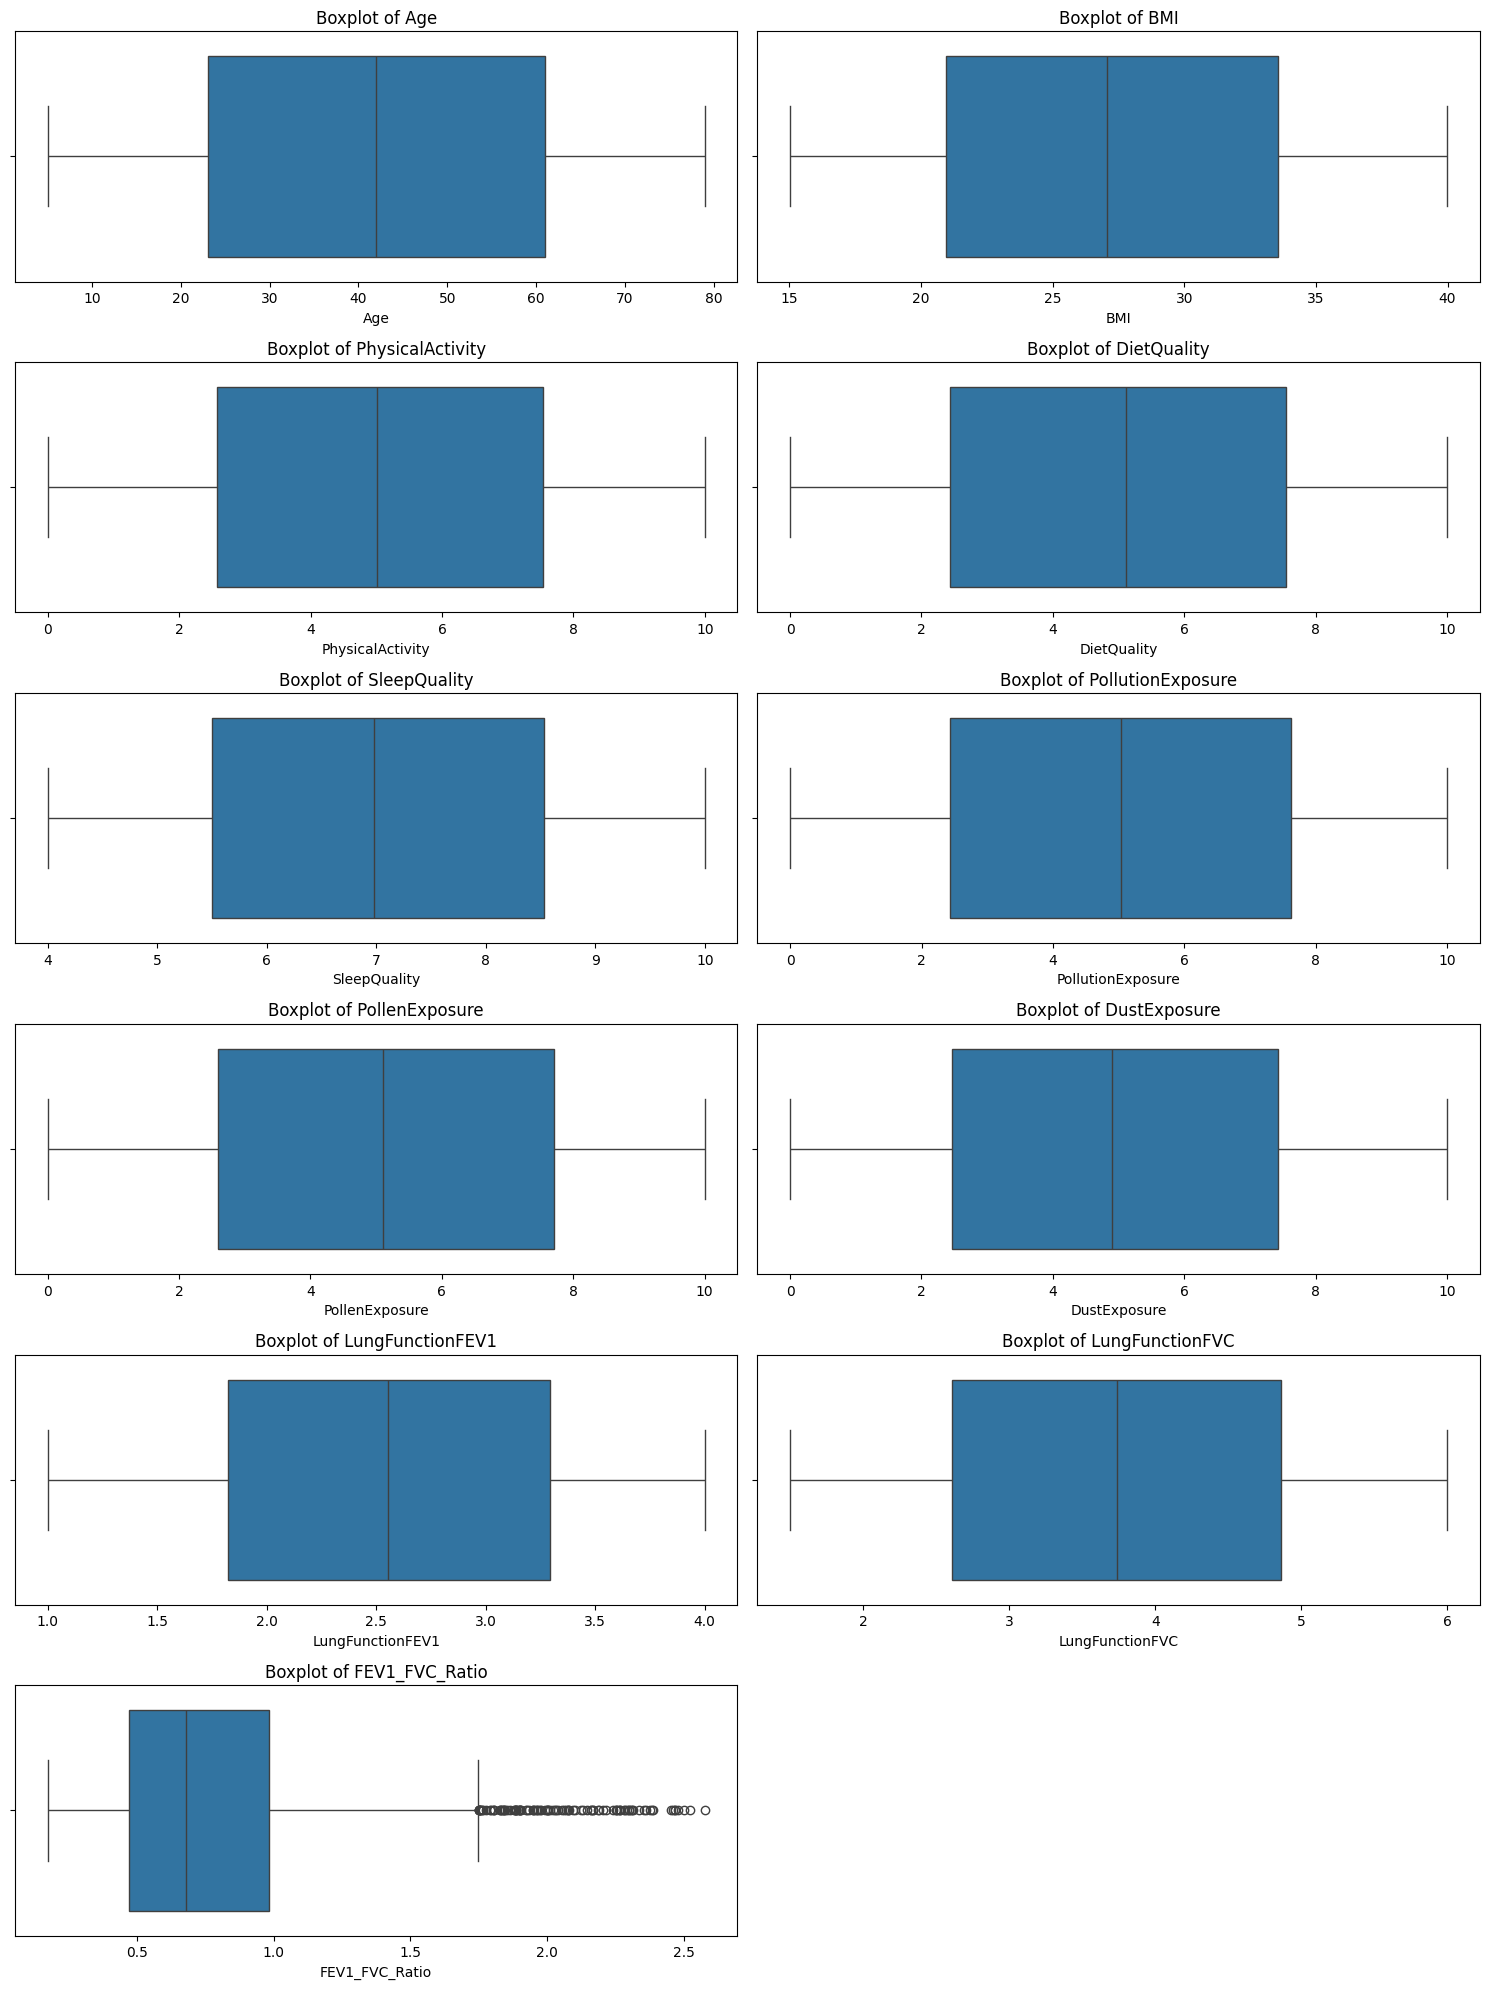

<Figure size 640x480 with 0 Axes>

In [10]:
# STEP 3: Create boxplots to visualize outliers
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 20))
for i, feature in enumerate(continuous_features):
    plt.subplot(6, 2, i + 1)
    sns.boxplot(x=df_cleaned[feature])
    plt.title(f"Boxplot of {feature}")
    plt.tight_layout()
plt.show()
plt.savefig("outliers.png")

# 3.categorical variable


In [24]:
# One-hot encode categorical variables
df_encoded = pd.get_dummies(df_cleaned, columns=["Ethnicity", "EducationLevel"], drop_first=True)

# Show the updated column names
print("Encoded columns:", df_encoded.columns.tolist())


Encoded columns: ['Age', 'Gender', 'BMI', 'Smoking', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'PollutionExposure', 'PollenExposure', 'DustExposure', 'PetAllergy', 'FamilyHistoryAsthma', 'HistoryOfAllergies', 'Eczema', 'HayFever', 'GastroesophagealReflux', 'LungFunctionFEV1', 'LungFunctionFVC', 'Wheezing', 'ShortnessOfBreath', 'ChestTightness', 'Coughing', 'NighttimeSymptoms', 'ExerciseInduced', 'Diagnosis', 'FEV1_FVC_Ratio', 'Ethnicity_1', 'Ethnicity_2', 'Ethnicity_3', 'EducationLevel_1', 'EducationLevel_2', 'EducationLevel_3']


In [29]:
df_encoded.to_csv("asthma_cleaned_dataset.csv", index=False)

print("✅ File saved successfully as 'asthma_cleaned_dataset.csv'")
df_encoded = df_cleaned.copy()  # No change


✅ File saved successfully as 'asthma_cleaned_dataset.csv'
